In [1]:
import pandas as pd
import tensorflow as tf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_db = "https://raw.githubusercontent.com/MSMRo/TINYML-PICO2-SIGNALS/refs/heads/main/DATASETS_TOY/data_tabular.csv"

df = pd.read_csv(path_db)
df.head()

,x,y,target
0,230.042076,346.177360,0
1,231.806889,356.356187,0
2,226.502447,348.140922,0
3,193.853666,334.864825,0
4,212.480927,360.686987,0


<Axes: xlabel='x', ylabel='y'>

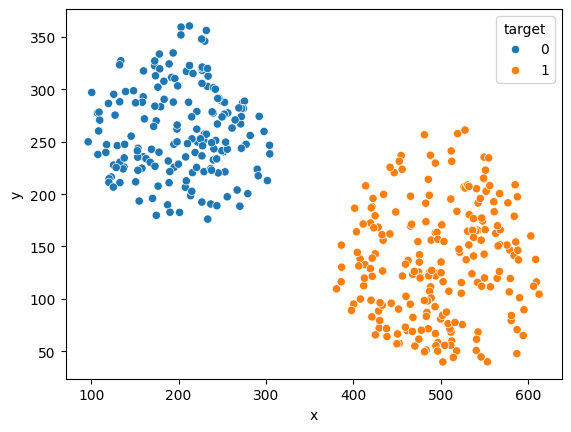

In [4]:
import seaborn as sns

sns.scatterplot(data=df, x='x', y='y', hue='target')

In [6]:
X = df[["x","y"]]
y = df["target"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

In [10]:
model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(4, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5830 - loss: 12.0370 - val_accuracy: 0.4884 - val_loss: 8.8241
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6641 - loss: 4.7655 - val_accuracy: 0.7364 - val_loss: 2.0963
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8726 - loss: 0.9444 - val_accuracy: 0.9690 - val_loss: 0.1322
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9961 - loss: 0.0117 - val_accuracy: 1.0000 - val_loss: 3.6009e-06
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9961 - loss: 0.0184 - val_accuracy: 1.0000 - val_loss: 1.6275e-04
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 4.7793e-05
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 4.5241e-05
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 6.1832e-04 - val_accuracy: 1.000

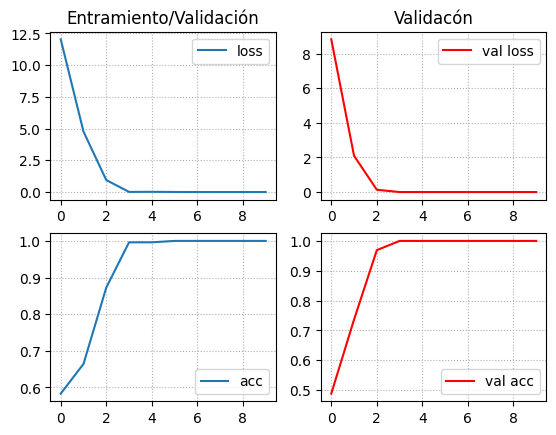

In [17]:
loss_ = history.history['loss']
val_loss_ = history.history['val_loss']

acc_ = history.history['accuracy']
val_acc_ = history.history['val_accuracy']

plt.subplot(2,2,1)
plt.title("Entramiento/Validación")
plt.plot(loss_, label='loss')
plt.legend()
plt.grid(ls=':')

plt.subplot(2,2,2)
plt.title("Validacón")
plt.plot(val_loss_, label='val loss', color="r")
plt.legend()
plt.grid(ls=':')

plt.subplot(2,2,3)
plt.plot(acc_, label='acc')
plt.legend()
plt.grid(ls=':')

plt.subplot(2,2,4)
plt.plot(val_acc_, label='val acc', color="r")
#plt.ylim([0,1])
plt.legend()
plt.grid(ls=':')

In [19]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model_2_categories.tflite",'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmphxg4_f4m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140342998495696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140342998497808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140343023838096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140343023839440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140342998493776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140342998495888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140342998496080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140342998492624: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [20]:
def convert_to_c_array(tflite_model, filename):
    with open(tflite_model, 'rb') as f:
        tflite_data = f.read()

    with open(filename, 'w') as f:
        f.write('#include <cstdint>\n')
        f.write(f'const unsigned char {tflite_model.replace(".tflite", "")}_tflite[] = {{\n')

        for i, byte in enumerate(tflite_data):
            if i % 12 == 0:
                f.write('\n  ')
            f.write(f'0x{byte:02x}, ')

        f.write('\n};\n')
        f.write(f'const unsigned int {tflite_model.replace(".tflite", "")}_tflite_len = {len(tflite_data)};\n')

# Example usage
convert_to_c_array('model_2_categories.tflite', 'model_2_categories.h')